Optimal Parameters:  [4.36779405e+02 5.98143831e+00 1.01012317e-02]
RMSE:  27.560363072632736
MAE:  14.07887457089919
R2 Score:  0.9506592969591001


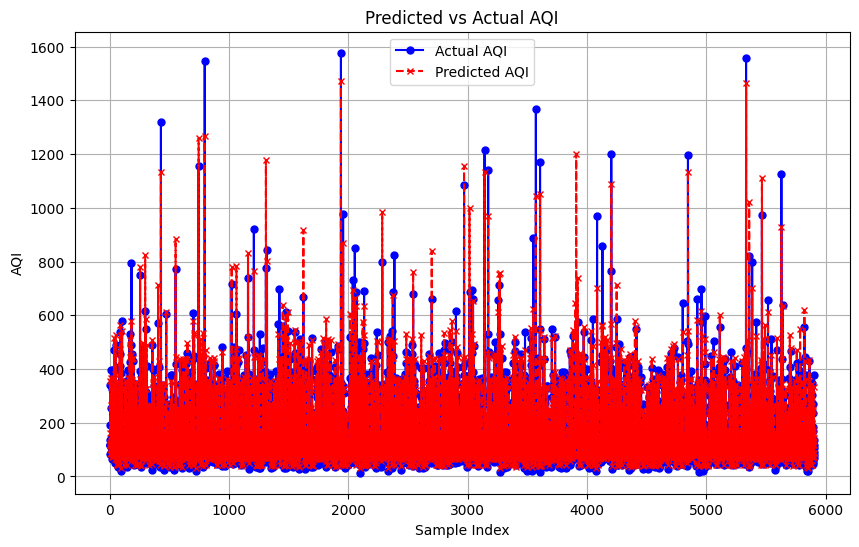

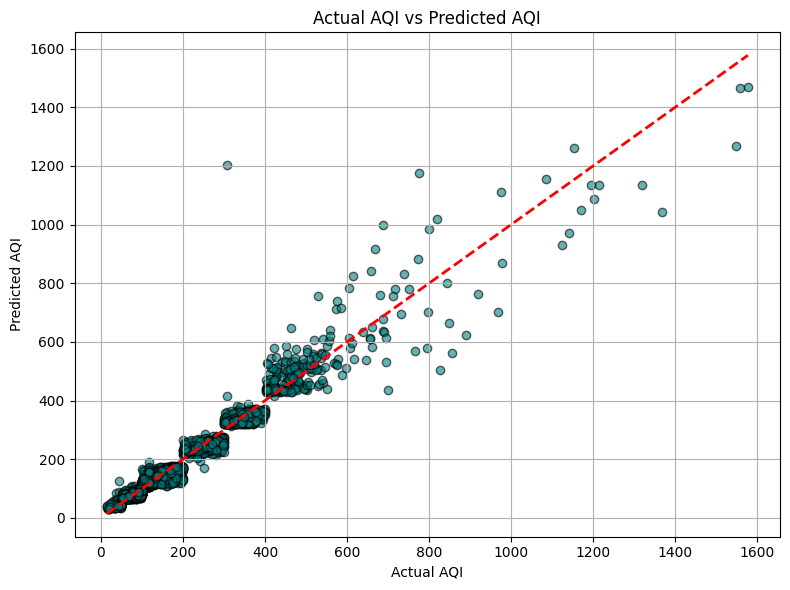

In [2]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Load Data
data = pd.read_csv("./AirQuality_Cleaned.csv")

# Parse Date Column and Drop it
data['Date'] = pd.to_datetime(data['Date'])
data.drop('Date', axis=1, inplace=True)

# Check for missing values
#print(data.isnull().sum())

# Splitting Data
X = data.drop('AQI', axis=1)
y = data['AQI']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grey Wolf Optimizer
class GreyWolfOptimizer:
    def __init__(self, n_wolves, max_iter, bounds):
        self.n_wolves = n_wolves
        self.max_iter = max_iter
        self.bounds = bounds

    def optimize(self, objective_function):
        wolves = np.random.uniform(low=[50, 3, 0.01], high=[500, 10, 0.3], size=(self.n_wolves, 3))
        alpha, beta, delta = wolves[0], wolves[1], wolves[2]

        for iteration in range(self.max_iter):
            for i, wolf in enumerate(wolves):
                wolf = np.clip(wolf, [50, 3, 0.01], [500, 10, 0.3])
                fitness = objective_function(wolf)
                if fitness < objective_function(alpha): alpha = wolf.copy()
                elif fitness < objective_function(beta): beta = wolf.copy()
                elif fitness < objective_function(delta): delta = wolf.copy()

            a = 2 - iteration * (2 / self.max_iter)
            for i, wolf in enumerate(wolves):
                for j in range(3):
                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_alpha = abs(C * alpha[j] - wolf[j])
                    X1 = alpha[j] - A * D_alpha

                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_beta = abs(C * beta[j] - wolf[j])
                    X2 = beta[j] - A * D_beta

                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_delta = abs(C * delta[j] - wolf[j])
                    X3 = delta[j] - A * D_delta

                    wolf[j] = (X1 + X2 + X3) / 3

        return alpha

# Objective Function
def objective_function(params):
    n_estimators = int(np.clip(params[0], 50, 500))
    max_depth = int(np.clip(params[1], 3, 10))
    learning_rate = np.clip(params[2], 0.01, 0.3)

    model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    # Validation
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    return rmse

# GWO Hyperparameters
bounds = [(50, 500), (3, 10), (0.01, 0.3)]
gwo = GreyWolfOptimizer(n_wolves=5, max_iter=10, bounds=bounds)  # Reduced to 10 iterations
optimal_params = gwo.optimize(objective_function)

# Final Model
n_estimators, max_depth, learning_rate = int(optimal_params[0]), int(optimal_params[1]), optimal_params[2]
final_model = XGBRegressor(n_estimators=n_estimators, max_depth=max_depth, learning_rate=learning_rate, random_state=42)
final_model.fit(X_train, y_train)

# Predictions
preds = final_model.predict(X_test)

# Evaluation
print("Optimal Parameters: ", optimal_params)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE: ", mean_absolute_error(y_test, preds))
print("R2 Score: ", r2_score(y_test, preds))


# Plot Predicted vs Actual AQI
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Actual AQI', color='blue', linestyle='-', marker='o', markersize=5)
plt.plot(preds, label='Predicted AQI', color='red', linestyle='--', marker='x', markersize=5)
plt.title('Predicted vs Actual AQI')
plt.xlabel('Sample Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

# Scatter Plot: Actual vs Predicted AQI
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.6, color='teal', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')  # Reference line (y = x)
plt.title('Actual AQI vs Predicted AQI')
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.grid(True)
plt.tight_layout()
plt.show()
